<a href="https://colab.research.google.com/github/erxuanqi/mental-health-app-ux-analysis/blob/main/notebooks/01_main_analysis_level1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mental Health App UX Analysis

## Main Analysis: Level 1–2

This notebook conducts the core analysis for the project.

Level 1 focuses on data loading, data cleaning, exploratory data analysis, and visualisation.

Level 2 focuses on high-rating versus low-rating review comparison, TF-IDF keyword analysis, rule-based pain point classification, and digital health design implications.

In [6]:
# Import basic Python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset Description

This project uses a public dataset of mental health app reviews. The dataset contains user-generated reviews and ratings from mental health-related mobile applications.

The analysis focuses on publicly available app review data rather than private clinical records, diagnosis information, treatment records, or patient-level health data.

The dataset will be used to explore user satisfaction, common pain points, and design implications for digital mental health products.

## 2. Import Libraries

The following Python libraries are used for data loading, cleaning, analysis, and visualisation.

## 3. Project Folder Setup

The following folders are created to organise data, figures, tables, and outputs generated during the analysis.

In [7]:
# Create project folders in the Colab working environment

import os

folders = [
    "data",
    "data/raw",
    "data/processed",
    "outputs",
    "outputs/figures",
    "outputs/tables",
    "outputs/models"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


## 4. Load Dataset

In this section, the MHARD mental health app review dataset will be loaded for analysis.

The dataset contains public user reviews of mental health-related mobile applications. The analysis will focus on review text, user ratings, app names, and other available metadata.

In [8]:
# Choose dataset version: "sample" or "full"

DATASET_VERSION = "full"

sample_url = "https://raw.githubusercontent.com/Sensify-Lab/MHARD/main/MHARD_dataset_sample.csv"
full_url = "https://raw.githubusercontent.com/Sensify-Lab/MHARD/main/MHARD_dataset.csv"

if DATASET_VERSION == "sample":
    dataset_url = sample_url
    dataset_path = "data/raw/MHARD_dataset_sample.csv"
elif DATASET_VERSION == "full":
    dataset_url = full_url
    dataset_path = "data/raw/MHARD_dataset.csv"
else:
    raise ValueError("DATASET_VERSION must be either 'sample' or 'full'.")

df = pd.read_csv(dataset_url)
df.to_csv(dataset_path, index=False)

print("Dataset version:", DATASET_VERSION)
print("Dataset loaded successfully.")
print("Dataset path:", dataset_path)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset version: full
Dataset loaded successfully.
Dataset path: data/raw/MHARD_dataset.csv
Number of rows: 200972
Number of columns: 16


## 5. Data Understanding

Before cleaning the dataset, I inspect its structure, including column names, data types, missing values, rating distribution, app coverage, and sample reviews.

This step helps identify which variables should be kept for the core Level 1–2 analysis and which variables may support later advanced NLP analysis.

In [13]:
# Check column names, dataset shape, and data types

print("Column names:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

Column names:
['UID', 'app_name', 'rating', 'date', 'review', 'review_cleaned', 'likes', 'response_date', 'response', 'pred_gpt3.5instruct', 'pred_gpt3.5turbo', 'pred_gpt4', 'pred_gemini1.5flash', 'pred_gemini1.5pro', 'pred_llama3.1_8b', 'pred_llama3.3_70b']

Dataset shape:
(200972, 16)

Data types:
UID                      int64
app_name                object
rating                   int64
date                    object
review                  object
review_cleaned          object
likes                    int64
response_date           object
response                object
pred_gpt3.5instruct    float64
pred_gpt3.5turbo       float64
pred_gpt4              float64
pred_gemini1.5flash    float64
pred_gemini1.5pro      float64
pred_llama3.1_8b       float64
pred_llama3.3_70b      float64
dtype: object


In [14]:
# Preview the first few rows of the full dataset

df.head()

,UID,app_name,rating,date,review,review_cleaned,likes,response_date,response,pred_gpt3.5instruct,pred_gpt3.5turbo,pred_gpt4,pred_gemini1.5flash,pred_gemini1.5pro,pred_llama3.1_8b,pred_llama3.3_70b
0,1,chiku,5,"August 17, 2020",I'm digging it. journaling everything I do dur...,im digging journaling everything day complaint...,30,"August 23, 2020",We have fixed the issue in our latest update (...,4.0,4.0,4.0,4.0,4.0,4.0,4.0
1,2,chiku,4,"December 22, 2020","I really like this app, however, the awesome s...",really like app however awesome smiley graphic...,18,"December 22, 2020",Thank you so much for taking out time to write...,4.0,4.0,4.0,4.0,4.0,4.0,4.0
2,3,chiku,5,"March 02, 2022","I love this. It's so calming, and relaxing, an...",love calming relaxing definitely one favorite ...,62,NaN,NaN,4.0,4.0,4.0,4.0,4.0,4.0,4.0
3,4,chiku,4,"April 27, 2023",This app is really great! Its has many feature...,app really great many feature thing apps pay p...,56,NaN,NaN,4.0,4.0,4.0,4.0,4.0,4.0,4.0
4,5,chiku,4,"April 10, 2023",This app used to be amazing but now whenever I...,app used amazing whenever try make story start...,59,"April 13, 2023",We are really sorry for the inconvenience. We ...,2.0,2.0,2.0,2.0,3.0,3.0,2.0


In [15]:
# Check missing values in each column

missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing values by column:")
print(missing_values)

Missing values by column:
response_date          148609
response               148609
pred_llama3.1_8b        10429
pred_gemini1.5flash      2403
pred_llama3.3_70b         885
pred_gpt4                 501
pred_gpt3.5instruct       305
review_cleaned            240
pred_gpt3.5turbo          191
pred_gemini1.5pro          54
review                     21
likes                       0
UID                         0
app_name                    0
rating                      0
date                        0
dtype: int64


In [16]:
# Check rating distribution

rating_counts = df["rating"].value_counts().sort_index()

print("Rating distribution:")
print(rating_counts)

Rating distribution:
rating
1     34582
2      8923
3     11111
4     25100
5    121256
Name: count, dtype: int64


In [17]:
# Check the number of unique apps

num_apps = df["app_name"].nunique()

print("Number of unique apps:", num_apps)

print("\nTop 10 apps by number of reviews:")
print(df["app_name"].value_counts().head(10))

Number of unique apps: 73

Top 10 apps by number of reviews:
app_name
digitalwellbeing    16712
intellect           16045
headspace           15323
fabulous            14327
daylio              13928
calm                 9751
sevencups            7384
sanvello             6563
gratitude            6169
minddoc              5761
Name: count, dtype: int64


## 6. Data Cleaning and Feature Engineering

In this section, I clean the dataset and create new variables for the core analysis.

The cleaned dataset will be used for Level 1–2 analysis and will also be saved for later advanced analysis, such as BERTopic, transformer-assisted classification, and BERT fine-tuning.

The main cleaning steps include:

- Keeping relevant columns
- Removing missing review text
- Removing duplicate reviews
- Creating rating groups
- Calculating review length and word count
- Creating a developer response indicator
- Preparing a clean text column for TF-IDF and later NLP analysis

In [9]:
# Data cleaning and feature engineering

# Make a copy of the original dataset
df_clean = df.copy()

# Keep the main columns needed for this project
main_columns = [
    "UID",
    "app_name",
    "rating",
    "date",
    "review",
    "review_cleaned",
    "likes",
    "response_date",
    "response"
]

df_clean = df_clean[main_columns]

# Remove rows with missing review text or missing rating
df_clean = df_clean.dropna(subset=["review", "rating"])

# Convert rating to numeric
df_clean["rating"] = pd.to_numeric(df_clean["rating"], errors="coerce")
df_clean = df_clean.dropna(subset=["rating"])
df_clean["rating"] = df_clean["rating"].astype(int)

# Remove duplicate reviews within the same app
df_clean = df_clean.drop_duplicates(subset=["app_name", "review"])

# Convert text columns to string
df_clean["review"] = df_clean["review"].astype(str)
df_clean["review_cleaned"] = df_clean["review_cleaned"].astype(str)

# Create rating groups
def create_rating_group(rating):
    if rating <= 2:
        return "Low rating"
    elif rating == 3:
        return "Neutral rating"
    else:
        return "High rating"

df_clean["rating_group"] = df_clean["rating"].apply(create_rating_group)

# Create text length features
df_clean["review_length"] = df_clean["review"].str.len()
df_clean["word_count"] = df_clean["review"].str.split().str.len()

# Create developer response indicator
df_clean["has_response"] = df_clean["response"].notnull()

# Use existing cleaned review text as the main clean text column
df_clean["clean_text"] = df_clean["review_cleaned"]

# Remove rows with empty clean text
df_clean = df_clean[df_clean["clean_text"].str.strip() != ""]

print("Data cleaning completed.")
print("Original number of rows:", df.shape[0])
print("Cleaned number of rows:", df_clean.shape[0])
print("Number of columns after cleaning:", df_clean.shape[1])

Data cleaning completed.
Original number of rows: 200972
Cleaned number of rows: 194774
Number of columns after cleaning: 14


In [19]:
# Check the cleaned dataset

print("Cleaned dataset shape:")
print(df_clean.shape)

print("\nRating group distribution:")
print(df_clean["rating_group"].value_counts())

print("\nPreview of selected columns:")
df_clean[["app_name", "rating", "rating_group", "review", "clean_text", "review_length", "word_count", "has_response"]].head()

Cleaned dataset shape:
(194774, 14)

Rating group distribution:
rating_group
High rating       141642
Low rating         42322
Neutral rating     10810
Name: count, dtype: int64

Preview of selected columns:


,app_name,rating,rating_group,review,clean_text,review_length,word_count,has_response
0,chiku,5,High rating,I'm digging it. journaling everything I do dur...,im digging journaling everything day complaint...,386,76,True
1,chiku,4,High rating,"I really like this app, however, the awesome s...",really like app however awesome smiley graphic...,500,94,True
2,chiku,5,High rating,"I love this. It's so calming, and relaxing, an...",love calming relaxing definitely one favorite ...,494,93,False
3,chiku,4,High rating,This app is really great! Its has many feature...,app really great many feature thing apps pay p...,493,99,False
4,chiku,4,High rating,This app used to be amazing but now whenever I...,app used amazing whenever try make story start...,309,59,True


## 7. Exploratory Data Analysis

This section explores the overall structure of user feedback in the cleaned dataset.

The analysis focuses on rating distribution, review volume by app, average rating by app, and review length patterns.

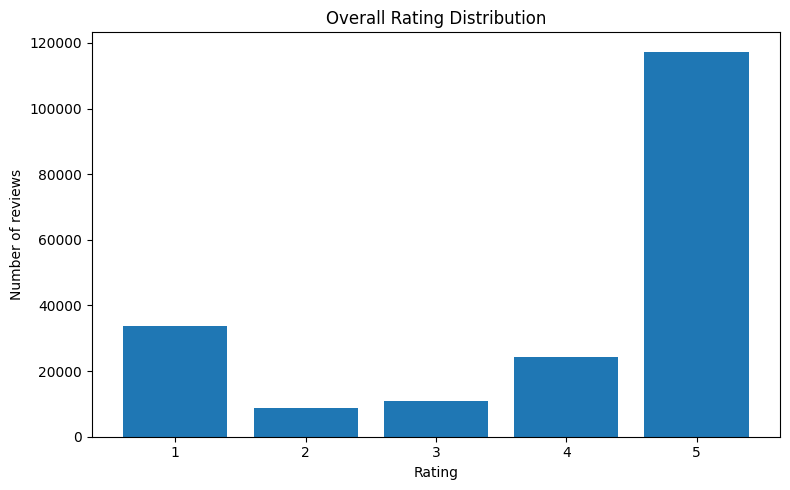

In [20]:
# Plot rating distribution

rating_counts = df_clean["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel("Rating")
plt.ylabel("Number of reviews")
plt.title("Overall Rating Distribution")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()

plt.savefig("outputs/figures/rating_distribution.png", dpi=300)
plt.show()

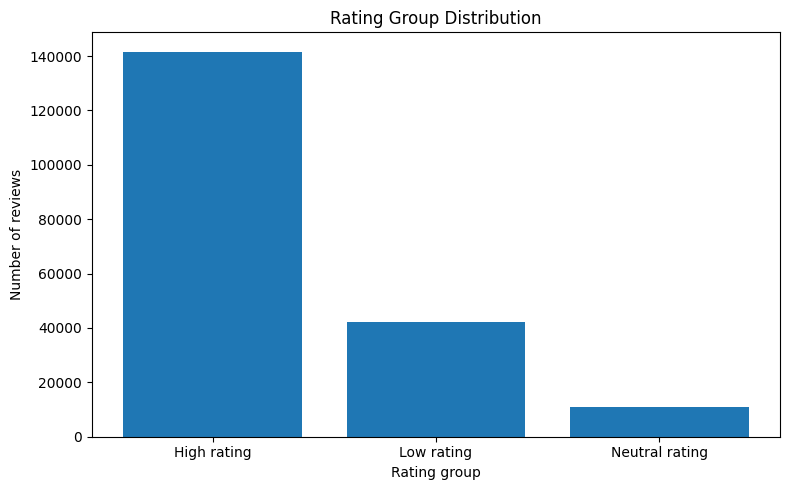

In [21]:
# Plot rating group distribution

rating_group_counts = df_clean["rating_group"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(rating_group_counts.index, rating_group_counts.values)
plt.xlabel("Rating group")
plt.ylabel("Number of reviews")
plt.title("Rating Group Distribution")
plt.tight_layout()

plt.savefig("outputs/figures/rating_group_distribution.png", dpi=300)
plt.show()

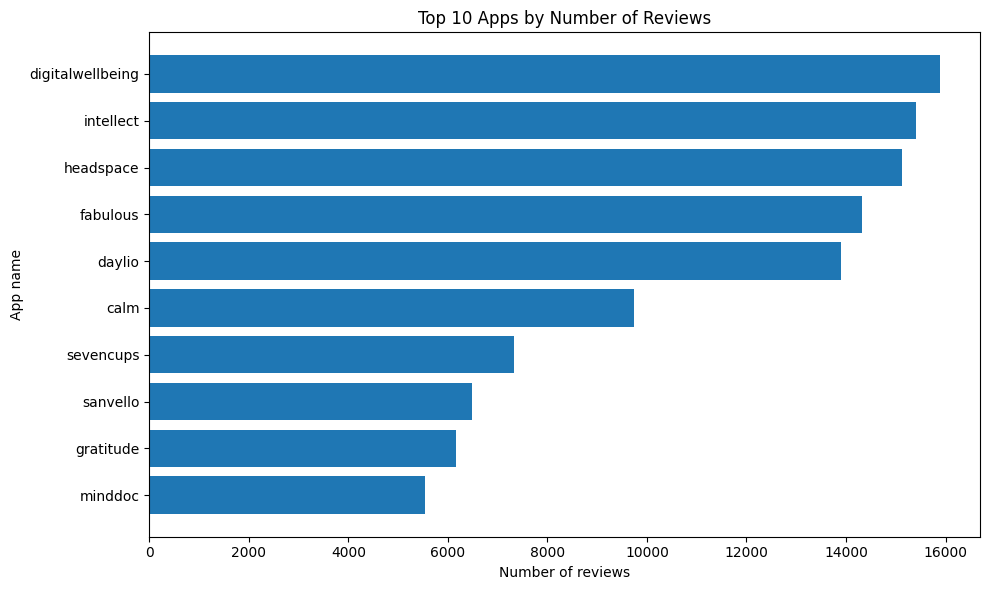

In [22]:
# Plot top 10 apps by number of reviews

top_apps = df_clean["app_name"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_apps.index[::-1], top_apps.values[::-1])
plt.xlabel("Number of reviews")
plt.ylabel("App name")
plt.title("Top 10 Apps by Number of Reviews")
plt.tight_layout()

plt.savefig("outputs/figures/top_10_apps_by_review_count.png", dpi=300)
plt.show()

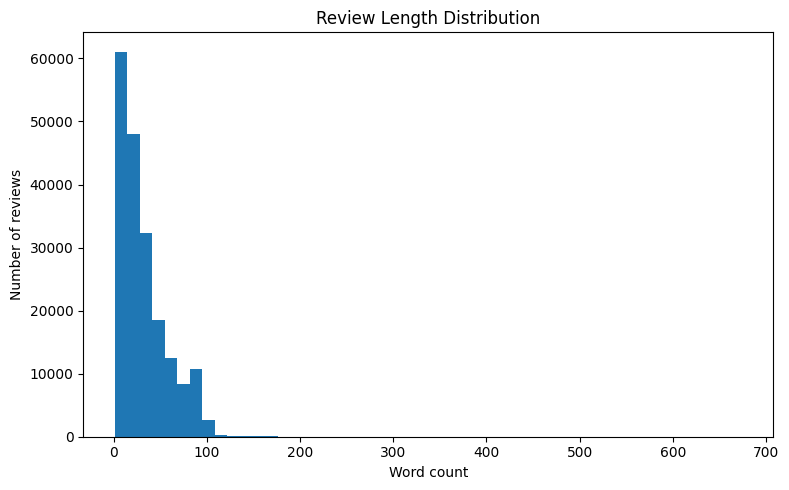

In [23]:
# Plot review length distribution

plt.figure(figsize=(8, 5))
plt.hist(df_clean["word_count"], bins=50)
plt.xlabel("Word count")
plt.ylabel("Number of reviews")
plt.title("Review Length Distribution")
plt.tight_layout()

plt.savefig("outputs/figures/review_length_distribution.png", dpi=300)
plt.show()

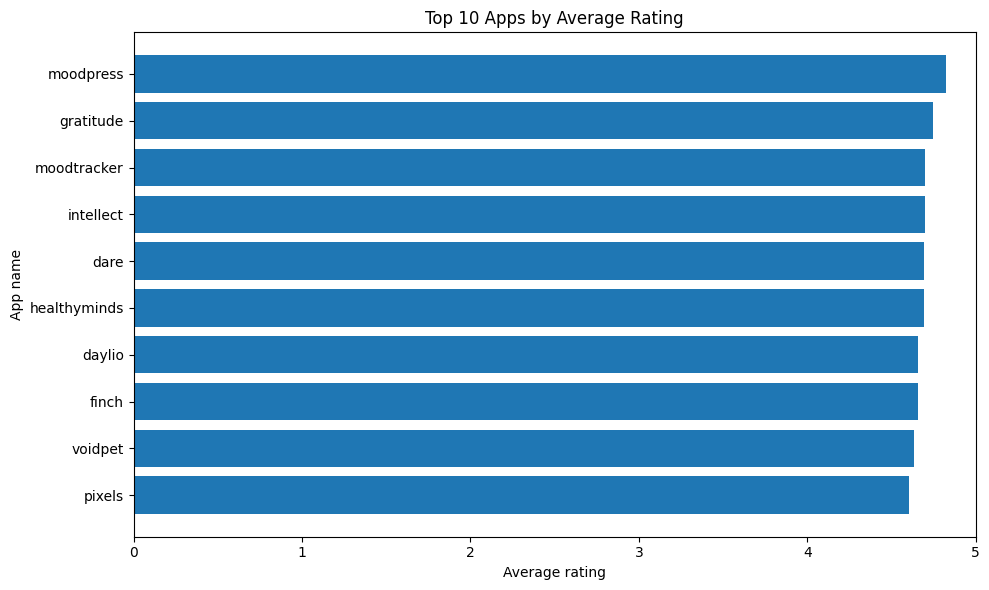

,app_name,review_count,average_rating
38,moodpress,1132,4.821555
23,gratitude,6166,4.746675
41,moodtracker,1120,4.700000
31,intellect,15400,4.698117
16,dare,2792,4.696275
27,healthyminds,837,4.694146
17,daylio,13907,4.659021
22,finch,3582,4.657454
66,voidpet,1010,4.632673
44,pixels,4619,4.604460


In [24]:
# Plot top 10 apps by average rating
# Only include apps with at least 500 reviews to avoid unstable averages

app_summary = df_clean.groupby("app_name").agg(
    review_count=("review", "count"),
    average_rating=("rating", "mean")
).reset_index()

app_summary_filtered = app_summary[app_summary["review_count"] >= 500]

top_avg_rating_apps = app_summary_filtered.sort_values(
    by="average_rating",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_avg_rating_apps["app_name"][::-1],
    top_avg_rating_apps["average_rating"][::-1]
)
plt.xlabel("Average rating")
plt.ylabel("App name")
plt.title("Top 10 Apps by Average Rating")
plt.xlim(0, 5)
plt.tight_layout()

plt.savefig("outputs/figures/top_10_apps_by_average_rating.png", dpi=300)
plt.show()

top_avg_rating_apps

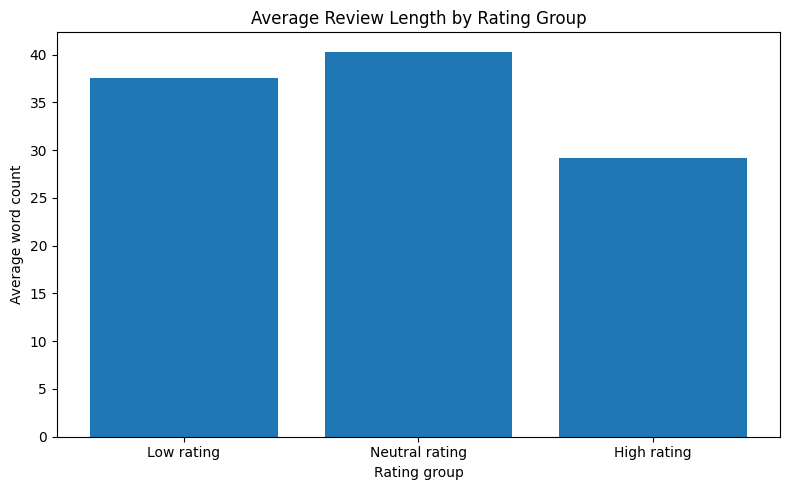

,word_count
rating_group,
Low rating,37.527196
Neutral rating,40.328215
High rating,29.156557


In [25]:
# Compare review length across rating groups

review_length_by_group = df_clean.groupby("rating_group")["word_count"].mean().reindex(
    ["Low rating", "Neutral rating", "High rating"]
)

plt.figure(figsize=(8, 5))
plt.bar(review_length_by_group.index, review_length_by_group.values)
plt.xlabel("Rating group")
plt.ylabel("Average word count")
plt.title("Average Review Length by Rating Group")
plt.tight_layout()

plt.savefig("outputs/figures/average_review_length_by_rating_group.png", dpi=300)
plt.show()

review_length_by_group

### Level 1 Summary

The exploratory analysis shows that the dataset contains a large number of public reviews across 73 mental health-related apps. The rating distribution is highly skewed toward 5-star reviews, but there is still a substantial number of low-rating reviews that can be used to examine user dissatisfaction and pain points.

The review volume also varies substantially across apps, suggesting that some apps dominate the dataset. Therefore, later app-level comparisons should consider review count as well as average rating.

Review length patterns provide an initial indication of how users express positive and negative experiences differently.

## 8. High-rating vs Low-rating Review Comparison

This section compares low-rating and high-rating reviews to understand how satisfied and dissatisfied users describe their experiences differently.

Low-rating reviews are defined as 1–2 star reviews, while high-rating reviews are defined as 4–5 star reviews.

This comparison provides the foundation for later TF-IDF keyword analysis and UX pain point classification.

In [26]:
# Create separate datasets for low-rating and high-rating reviews

low_reviews = df_clean[df_clean["rating_group"] == "Low rating"].copy()
high_reviews = df_clean[df_clean["rating_group"] == "High rating"].copy()

print("Number of low-rating reviews:", low_reviews.shape[0])
print("Number of high-rating reviews:", high_reviews.shape[0])

print("\nLow-rating review percentage:")
print(round(low_reviews.shape[0] / df_clean.shape[0] * 100, 2), "%")

print("\nHigh-rating review percentage:")
print(round(high_reviews.shape[0] / df_clean.shape[0] * 100, 2), "%")

Number of low-rating reviews: 42322
Number of high-rating reviews: 141642

Low-rating review percentage:
21.73 %

High-rating review percentage:
72.72 %


In [27]:
# Preview sample low-rating reviews

low_reviews[["app_name", "rating", "review", "clean_text", "word_count"]].head(10)

,app_name,rating,review,clean_text,word_count
5,chiku,1,"Right after i updated, the next time i opened ...",right updated next time opened app previous st...,55
9,chiku,1,I updated the app and It deleted all of my jou...,updated app deleted journal entry year memory ...,31
15,chiku,1,"Even after the update, this app is still crash...",even update app still crashing write journal l...,24
22,chiku,1,This has left me with a bad experience as I fo...,left bad experience found couldnt find way del...,96
32,chiku,1,Yearly fee to add images to entries (every oth...,yearly fee add image entry every diary app ive...,47
40,chiku,2,This app is attractive and easy to use. I real...,app attractive easy use really enjoyed format ...,62
68,chiku,1,Journal is free - mood tracking is not. Found ...,journal free mood tracking found bit misleadin...,22
82,chiku,1,Impossible to delete account because it says t...,impossible delete account say password wrong d...,40
86,chiku,2,Unable to delete account as it kept asking for...,unable delete account kept asking password log...,42
113,chiku,1,"I really want to give this app a try, but now ...",really want give app try keep force closing cr...,29


In [28]:
# Preview sample high-rating reviews

high_reviews[["app_name", "rating", "review", "clean_text", "word_count"]].head(10)

,app_name,rating,review,clean_text,word_count
0,chiku,5,I'm digging it. journaling everything I do dur...,im digging journaling everything day complaint...,76
1,chiku,4,"I really like this app, however, the awesome s...",really like app however awesome smiley graphic...,94
2,chiku,5,"I love this. It's so calming, and relaxing, an...",love calming relaxing definitely one favorite ...,93
3,chiku,4,This app is really great! Its has many feature...,app really great many feature thing apps pay p...,99
4,chiku,4,This app used to be amazing but now whenever I...,app used amazing whenever try make story start...,59
7,chiku,5,Amazing app. It has functions to follow your m...,amazing app function follow mood draw pictures...,58
8,chiku,5,"Cute, simple, and aesthetic theme. It's super ...",cute simple aesthetic theme super easy use lov...,26
10,chiku,5,"It's amazing! 💫 You can enter journal entries,...",amazing enter journal entry add picture pin da...,32
12,chiku,5,"You have a lot of options to choose from, eith...",lot option choose either theme mood activity o...,89
13,chiku,5,"I absolutely love Chiku. The daily tasks, the ...",absolutely love chiku daily task brilliant wel...,60


In [29]:
# Compare descriptive statistics of word count between low-rating and high-rating reviews

length_comparison = df_clean[df_clean["rating_group"].isin(["Low rating", "High rating"])].groupby(
    "rating_group"
)["word_count"].describe()

length_comparison

,count,mean,std,min,25%,50%,75%,max
rating_group,,,,,,,,
High rating,141642.0,29.156557,24.522559,1.0,11.0,22.0,40.0,674.0
Low rating,42322.0,37.527196,28.646459,1.0,15.0,30.0,55.0,441.0


## 9. TF-IDF Keyword Analysis

This section uses TF-IDF to identify important words and phrases in low-rating and high-rating reviews.

Instead of only counting frequent words, TF-IDF highlights terms that are more distinctive within a group of reviews. This helps compare what dissatisfied users complain about and what satisfied users praise.

In [30]:
# Import TF-IDF tools

from sklearn.feature_extraction.text import TfidfVectorizer

print("TF-IDF tools imported successfully.")

TF-IDF tools imported successfully.


In [31]:
# Prepare text data for TF-IDF analysis

low_texts = low_reviews["clean_text"].dropna().astype(str)
high_texts = high_reviews["clean_text"].dropna().astype(str)

print("Number of low-rating texts:", len(low_texts))
print("Number of high-rating texts:", len(high_texts))

Number of low-rating texts: 42322
Number of high-rating texts: 141642


In [33]:
# Define a function to extract top TF-IDF keywords

def get_top_tfidf_terms(texts, max_features=5000, ngram_range=(1, 2), top_n=30):
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        stop_words="english",
        ngram_range=ngram_range,
        min_df=5
    )

    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    mean_scores = tfidf_matrix.mean(axis=0).A1

    tfidf_df = pd.DataFrame({
        "term": feature_names,
        "tfidf_score": mean_scores
    }).sort_values(by="tfidf_score", ascending=False)

    return tfidf_df.head(top_n)

In [34]:
# Extract top TF-IDF terms from low-rating reviews

low_tfidf_terms = get_top_tfidf_terms(low_texts, top_n=30)

low_tfidf_terms

,term,tfidf_score
197,app,0.051479
1738,free,0.023380
1359,dont,0.022915
3130,phone,0.019325
3010,pay,0.018313
4621,use,0.017854
4735,want,0.016793
4313,time,0.016382
2419,like,0.016230
4089,subscription,0.015682


In [35]:
# Extract top TF-IDF terms from high-rating reviews

high_tfidf_terms = get_top_tfidf_terms(high_texts, top_n=30)

high_tfidf_terms

,term,tfidf_score
220,app,0.055187
2773,love,0.031132
3599,really,0.027141
2028,help,0.027034
1858,great,0.026935
1779,good,0.026005
2605,like,0.020617
2160,helpful,0.020601
1063,day,0.018850
4633,use,0.016794


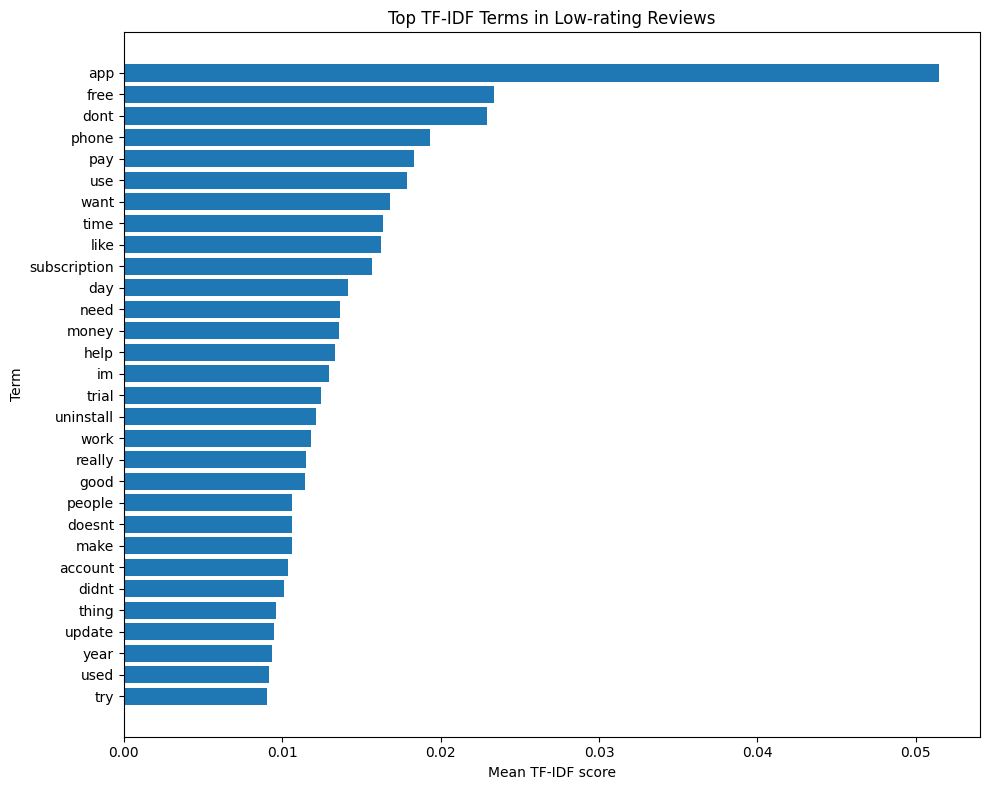

In [36]:
# Plot top TF-IDF terms for low-rating reviews

plt.figure(figsize=(10, 8))
plt.barh(low_tfidf_terms["term"][::-1], low_tfidf_terms["tfidf_score"][::-1])
plt.xlabel("Mean TF-IDF score")
plt.ylabel("Term")
plt.title("Top TF-IDF Terms in Low-rating Reviews")
plt.tight_layout()

plt.savefig("outputs/figures/low_rating_tfidf_terms.png", dpi=300)
plt.show()

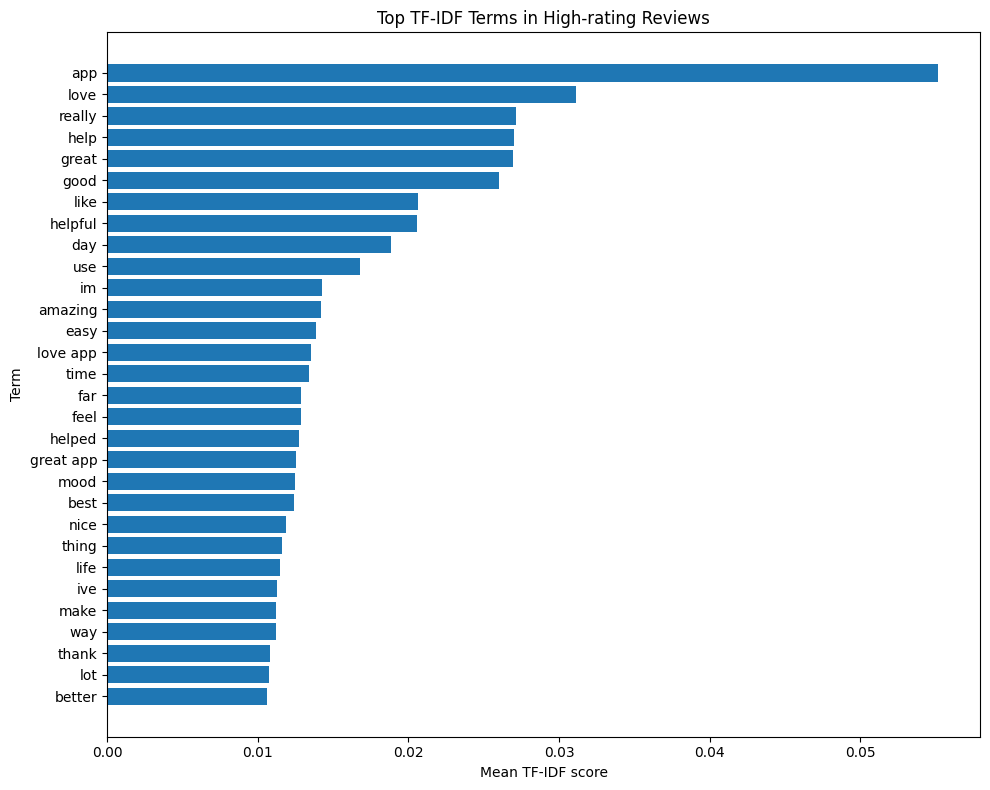

In [37]:
# Plot top TF-IDF terms for high-rating reviews

plt.figure(figsize=(10, 8))
plt.barh(high_tfidf_terms["term"][::-1], high_tfidf_terms["tfidf_score"][::-1])
plt.xlabel("Mean TF-IDF score")
plt.ylabel("Term")
plt.title("Top TF-IDF Terms in High-rating Reviews")
plt.tight_layout()

plt.savefig("outputs/figures/high_rating_tfidf_terms.png", dpi=300)
plt.show()

In [38]:
# Improve TF-IDF analysis by adding project-specific stopwords

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "app", "apps", "im", "ive", "dont", "doesnt", "didnt",
    "really", "just", "like", "good", "great", "thing", "things",
    "make", "makes", "use", "using", "used", "want", "way",
    "day", "time", "lot", "people", "feel", "need", "got",
    "get", "know", "think", "better", "best", "nice"
})

def get_top_tfidf_terms_refined(texts, max_features=8000, ngram_range=(1, 2), top_n=30):
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        stop_words=list(custom_stopwords),
        ngram_range=ngram_range,
        min_df=10
    )

    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    mean_scores = tfidf_matrix.mean(axis=0).A1

    tfidf_df = pd.DataFrame({
        "term": feature_names,
        "tfidf_score": mean_scores
    }).sort_values(by="tfidf_score", ascending=False)

    return tfidf_df.head(top_n)

print("Refined TF-IDF function created successfully.")

Refined TF-IDF function created successfully.


In [39]:
# Extract refined TF-IDF terms from low-rating reviews

low_tfidf_terms_refined = get_top_tfidf_terms_refined(low_texts, top_n=30)

low_tfidf_terms_refined

,term,tfidf_score
2286,free,0.024274
4425,phone,0.021036
4248,pay,0.019779
5998,subscription,0.016001
3772,money,0.014299
2717,help,0.014188
6761,uninstall,0.013760
7216,work,0.012952
6469,trial,0.012747
89,account,0.010520


In [40]:
# Extract refined TF-IDF terms from high-rating reviews

high_tfidf_terms_refined = get_top_tfidf_terms_refined(high_texts, top_n=30)

high_tfidf_terms_refined

,term,tfidf_score
4268,love,0.034097
3043,help,0.030521
3350,helpful,0.022890
293,amazing,0.015531
1849,easy,0.015437
2270,far,0.015334
3262,helped,0.013990
4809,mood,0.013200
4036,life,0.012021
7019,thank,0.011452


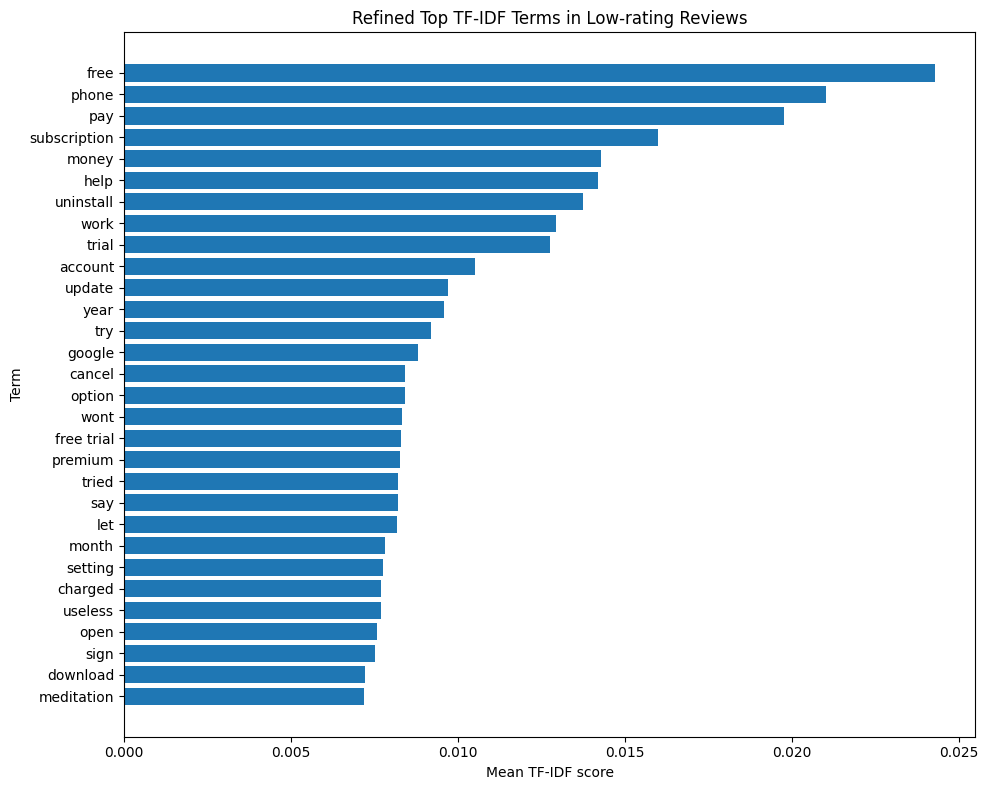

In [41]:
# Plot refined top TF-IDF terms for low-rating reviews

plt.figure(figsize=(10, 8))
plt.barh(
    low_tfidf_terms_refined["term"][::-1],
    low_tfidf_terms_refined["tfidf_score"][::-1]
)
plt.xlabel("Mean TF-IDF score")
plt.ylabel("Term")
plt.title("Refined Top TF-IDF Terms in Low-rating Reviews")
plt.tight_layout()

plt.savefig("outputs/figures/refined_low_rating_tfidf_terms.png", dpi=300)
plt.show()

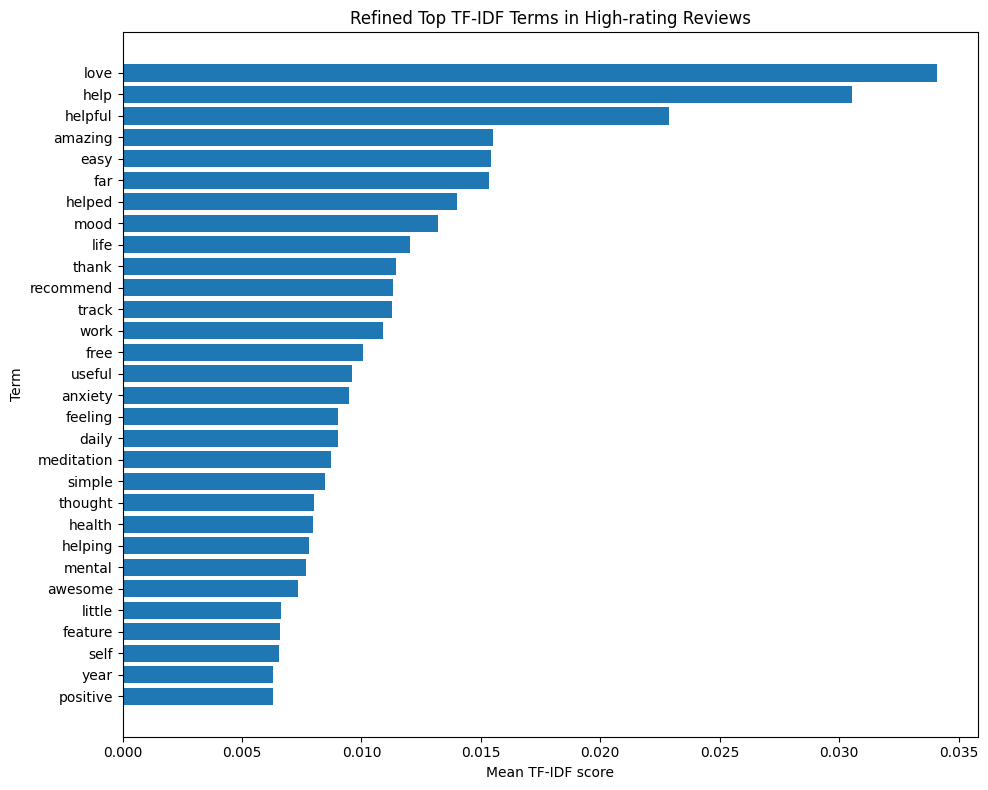

In [42]:
# Plot refined top TF-IDF terms for high-rating reviews

plt.figure(figsize=(10, 8))
plt.barh(
    high_tfidf_terms_refined["term"][::-1],
    high_tfidf_terms_refined["tfidf_score"][::-1]
)
plt.xlabel("Mean TF-IDF score")
plt.ylabel("Term")
plt.title("Refined Top TF-IDF Terms in High-rating Reviews")
plt.tight_layout()

plt.savefig("outputs/figures/refined_high_rating_tfidf_terms.png", dpi=300)
plt.show()

## 10. User Pain Point Classification

This section applies a rule-based classification approach to identify recurring UX pain points in low-rating reviews.

The categories are based on the TF-IDF keyword analysis and sample review inspection. This approach allows the project to translate unstructured user feedback into interpretable UX and digital health design themes.

The rule-based categories are not intended to replace manual qualitative coding, but they provide a scalable first step for analysing large volumes of app review data.

In [43]:
# Define rule-based pain point categories using keyword dictionaries

pain_point_keywords = {
    "Pricing / Subscription": [
        "pay", "paid", "payment", "price", "pricing", "money", "cost",
        "subscription", "subscribe", "premium", "trial", "free trial",
        "charge", "charged", "billing", "refund", "cancel"
    ],

    "Technical Issues": [
        "bug", "bugs", "crash", "crashes", "crashing", "freeze", "frozen",
        "glitch", "error", "errors", "update", "download", "install",
        "uninstall", "phone", "screen", "loading", "load", "slow"
    ],

    "Account / Login Issues": [
        "account", "login", "log in", "sign in", "signin", "password",
        "email", "delete account", "unable to login", "reset"
    ],

    "Usability / Interface": [
        "confusing", "hard", "difficult", "interface", "layout", "navigation",
        "button", "settings", "option", "options", "feature", "features"
    ],

    "Content Quality / Effectiveness": [
        "useless", "help", "helpful", "unhelpful", "advice", "content",
        "meditation", "therapy", "journal", "mood", "anxiety", "sleep",
        "does not work", "did not help", "not helpful"
    ],

    "Customer Support": [
        "support", "customer", "service", "reply", "response", "contact",
        "developer", "help desk"
    ],

    "Privacy / Trust": [
        "privacy", "data", "personal", "safe", "trust", "secure",
        "security", "permission", "permissions"
    ]
}

print("Pain point keyword dictionary created.")
print("Number of categories:", len(pain_point_keywords))

Pain point keyword dictionary created.
Number of categories: 7


In [44]:
# Create a function to classify reviews into pain point categories

def classify_pain_point(text):
    text = str(text).lower()

    matched_categories = []

    for category, keywords in pain_point_keywords.items():
        for keyword in keywords:
            if keyword in text:
                matched_categories.append(category)
                break

    if len(matched_categories) == 0:
        return "Other / Unclassified"
    else:
        return "; ".join(matched_categories)

print("Pain point classification function created.")

Pain point classification function created.


In [45]:
# Apply rule-based pain point classification to low-rating reviews

low_reviews = low_reviews.copy()
low_reviews["pain_point_category"] = low_reviews["clean_text"].apply(classify_pain_point)

print("Pain point classification completed for low-rating reviews.")

print("\nPain point category distribution:")
print(low_reviews["pain_point_category"].value_counts().head(20))

Pain point classification completed for low-rating reviews.

Pain point category distribution:
pain_point_category
Other / Unclassified                                                              8412
Technical Issues                                                                  6342
Pricing / Subscription                                                            4957
Pricing / Subscription; Content Quality / Effectiveness                           2503
Content Quality / Effectiveness                                                   2155
Pricing / Subscription; Technical Issues                                          1793
Technical Issues; Content Quality / Effectiveness                                 1136
Pricing / Subscription; Technical Issues; Content Quality / Effectiveness          971
Account / Login Issues                                                             822
Pricing / Subscription; Customer Support                                           819
Pricing / Subsc

In [46]:
# Count pain point categories, allowing one review to belong to multiple categories

pain_point_expanded = low_reviews.assign(
    pain_point_category=low_reviews["pain_point_category"].str.split("; ")
).explode("pain_point_category")

pain_point_counts = pain_point_expanded["pain_point_category"].value_counts().reset_index()
pain_point_counts.columns = ["pain_point_category", "count"]

pain_point_counts

,pain_point_category,count
0,Pricing / Subscription,17449
1,Technical Issues,15419
2,Content Quality / Effectiveness,10868
3,Other / Unclassified,8412
4,Usability / Interface,5198
5,Account / Login Issues,4915
6,Customer Support,4725
7,Privacy / Trust,2647


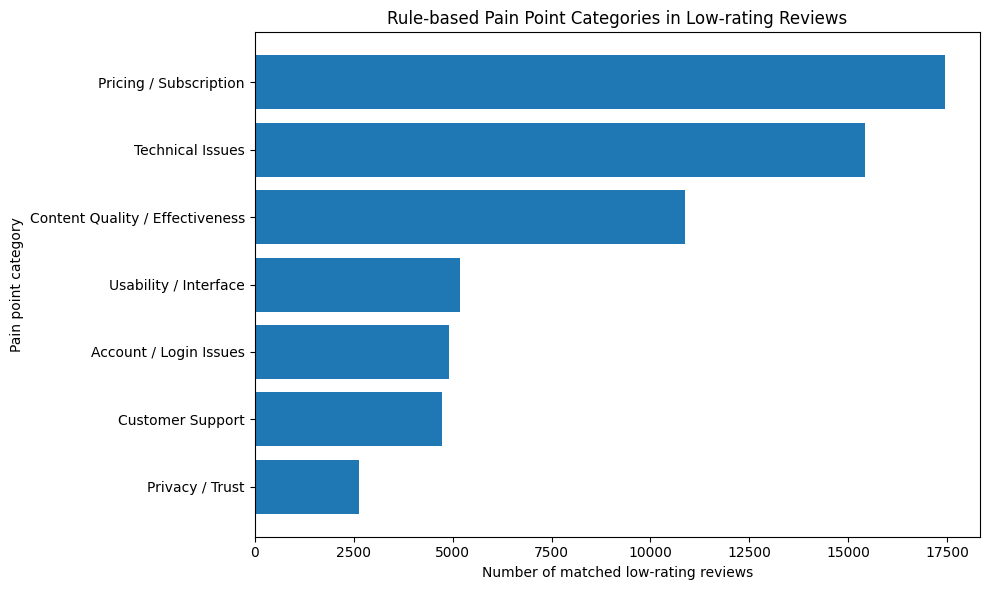

In [47]:
# Plot pain point category distribution

pain_point_plot = pain_point_counts[pain_point_counts["pain_point_category"] != "Other / Unclassified"]

plt.figure(figsize=(10, 6))
plt.barh(
    pain_point_plot["pain_point_category"][::-1],
    pain_point_plot["count"][::-1]
)
plt.xlabel("Number of matched low-rating reviews")
plt.ylabel("Pain point category")
plt.title("Rule-based Pain Point Categories in Low-rating Reviews")
plt.tight_layout()

plt.savefig("outputs/figures/pain_point_category_distribution.png", dpi=300)
plt.show()

In [49]:
# Show example reviews for each pain point category

for category in pain_point_keywords.keys():
    print("\n" + "="*80)
    print("Category:", category)
    print("="*80)

    examples = low_reviews[
        low_reviews["pain_point_category"].str.contains(category, regex=False)
    ][["app_name", "rating", "review"]].head(3)

    for idx, row in examples.iterrows():
        print("\nApp:", row["app_name"])
        print("Rating:", row["rating"])
        print("Review:", row["review"][:500])


Category: Pricing / Subscription

App: chiku
Rating: 2
Review: This app is attractive and easy to use. I really enjoyed the format however I have a Google pixel 4 phone and when the new update for Google was installed (12) the app was no longer working in fact I can't even install it on my phone. I had just purchased the app recently so please correct this or refund my purchase

App: chiku
Rating: 2
Review: I wish you update this app more often especially cause I subscribed to your app. Add more activities, be more organized.

App: chiku
Rating: 1
Review: Premium adds literally nothing. Hope this gets more content in the future.

Category: Technical Issues

App: chiku
Rating: 1
Review: Right after i updated, the next time i opened the app all my previous stories had disappeared. Even when i tried to make a story it said no network and wouldn't upload. This app is broken. Used to be very easy to make entries. Now it doesn't even work and you lost everything you've done.

App: chiku
Rat


### 10.1 Refined Pain Point Classification

The initial rule-based classification showed that some broad keywords may over-classify reviews into general categories. Therefore, the keyword dictionary is refined to improve interpretability.

The refined categories focus on more specific UX pain points, such as subscription issues, technical failures, account access problems, usability barriers, content effectiveness, customer support, and privacy or trust concerns.

In [1]:
# Refine pain point keyword dictionary with more specific terms

refined_pain_point_keywords = {
    "Pricing / Subscription": [
        "pay", "paid", "payment", "price", "pricing", "money", "cost",
        "subscription", "subscribe", "premium", "trial", "free trial",
        "charge", "charged", "billing", "refund", "cancel subscription",
        "paywall", "monthly", "yearly"
    ],

    "Technical Issues": [
        "bug", "bugs", "crash", "crashes", "crashing", "freeze", "frozen",
        "glitch", "error", "errors", "update", "download", "install",
        "uninstall", "loading", "load", "slow", "broken", "network",
        "sync", "lost", "deleted", "disappeared"
    ],

    "Account / Login Issues": [
        "account", "login", "log in", "sign in", "signin", "password",
        "email", "delete account", "reset password", "cannot login",
        "unable to login", "locked out"
    ],

    "Usability / Interface": [
        "confusing", "hard to use", "difficult to use", "interface",
        "layout", "navigation", "button", "settings", "option",
        "options", "feature", "features", "tedious", "complicated",
        "difficult", "hard"
    ],

    "Content Quality / Effectiveness": [
        "not helpful", "unhelpful", "useless", "generic", "repetitive",
        "superficial", "boring", "limited content", "not useful",
        "does not help", "did not help", "doesn't help",
        "bad advice", "poor advice", "not effective"
    ],

    "Customer Support": [
        "customer support", "customer service", "support team",
        "emailed support", "contact support", "no response",
        "never replied", "refund request", "help desk"
    ],

    "Privacy / Trust": [
        "privacy", "personal data", "data privacy", "safe", "trust",
        "secure", "security", "permission", "permissions",
        "invasive", "delete journal", "delete entries"
    ]
}

print("Refined pain point keyword dictionary created.")
print("Number of refined categories:", len(refined_pain_point_keywords))

Refined pain point keyword dictionary created.
Number of refined categories: 7


In [2]:
# Create refined classification function

def classify_refined_pain_point(text):
    text = str(text).lower()

    matched_categories = []

    for category, keywords in refined_pain_point_keywords.items():
        for keyword in keywords:
            if keyword in text:
                matched_categories.append(category)
                break

    if len(matched_categories) == 0:
        return "Other / Unclassified"
    else:
        return "; ".join(matched_categories)

print("Refined pain point classification function created.")

Refined pain point classification function created.


In [11]:
# Apply refined rule-based pain point classification to low-rating reviews

low_reviews["refined_pain_point_category"] = low_reviews["clean_text"].apply(classify_refined_pain_point)

print("Refined pain point classification completed.")

print("\nRefined pain point category distribution:")
print(low_reviews["refined_pain_point_category"].value_counts().head(20))

Refined pain point classification completed.

Refined pain point category distribution:
refined_pain_point_category
Other / Unclassified                                                     12460
Pricing / Subscription                                                    8358
Technical Issues                                                          6445
Pricing / Subscription; Technical Issues                                  3009
Pricing / Subscription; Usability / Interface                             1546
Usability / Interface                                                     1217
Pricing / Subscription; Account / Login Issues                            1181
Account / Login Issues                                                    1134
Technical Issues; Usability / Interface                                    796
Technical Issues; Account / Login Issues                                   646
Pricing / Subscription; Technical Issues; Usability / Interface            631
Pricing / Subsc

In [12]:
# Count refined pain point categories, allowing one review to belong to multiple categories

refined_pain_point_expanded = low_reviews.assign(
    refined_pain_point_category=low_reviews["refined_pain_point_category"].str.split("; ")
).explode("refined_pain_point_category")

refined_pain_point_counts = refined_pain_point_expanded["refined_pain_point_category"].value_counts().reset_index()
refined_pain_point_counts.columns = ["pain_point_category", "count"]

refined_pain_point_counts

,pain_point_category,count
0,Pricing / Subscription,17248
1,Technical Issues,13633
2,Other / Unclassified,12460
3,Usability / Interface,5293
4,Account / Login Issues,4722
5,Content Quality / Effectiveness,1633
6,Privacy / Trust,1277
7,Customer Support,975


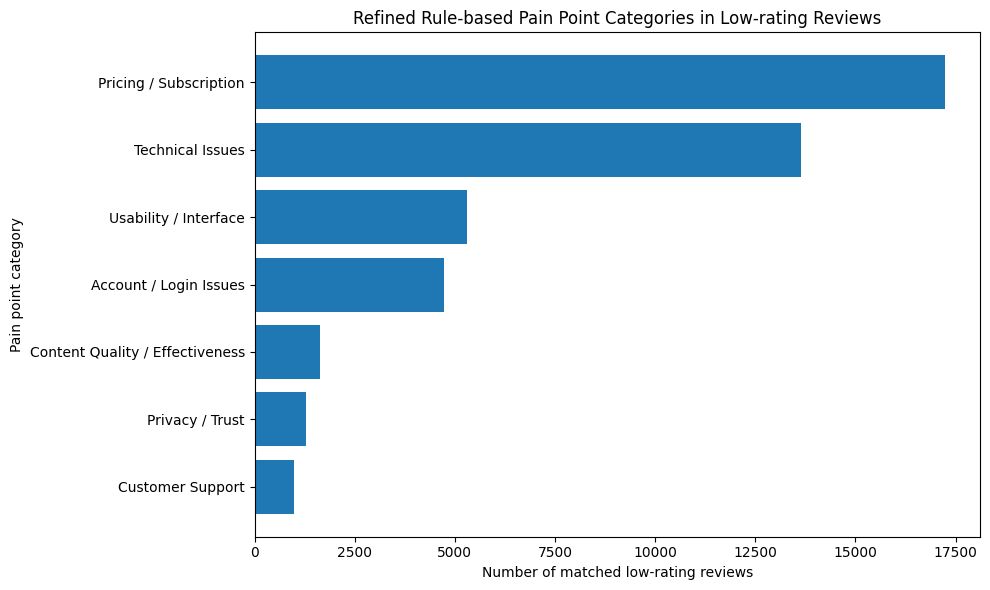

In [13]:
# Plot refined pain point category distribution

refined_pain_point_plot = refined_pain_point_counts[
    refined_pain_point_counts["pain_point_category"] != "Other / Unclassified"
]

plt.figure(figsize=(10, 6))
plt.barh(
    refined_pain_point_plot["pain_point_category"][::-1],
    refined_pain_point_plot["count"][::-1]
)
plt.xlabel("Number of matched low-rating reviews")
plt.ylabel("Pain point category")
plt.title("Refined Rule-based Pain Point Categories in Low-rating Reviews")
plt.tight_layout()

plt.savefig("outputs/figures/refined_pain_point_category_distribution.png", dpi=300)
plt.show()

In [15]:
# Show example reviews for each refined pain point category

for category in refined_pain_point_keywords.keys():
    print("\n" + "="*80)
    print("Category:", category)
    print("="*80)

    examples = low_reviews[
        low_reviews["refined_pain_point_category"].str.contains(category, regex=False)
    ][["app_name", "rating", "review"]].head(3)

    for idx, row in examples.iterrows():
        print("\nApp:", row["app_name"])
        print("Rating:", row["rating"])
        print("Review:", row["review"][:500])


Category: Pricing / Subscription

App: chiku
Rating: 1
Review: Yearly fee to add images to entries (every other diary app I've tried does this free), cannot skip moods or icons for entries and just write, like 10 tedious steps just to get to writing anything. Ugh, tedious. Also, have to make an account and login. XP

App: chiku
Rating: 2
Review: This app is attractive and easy to use. I really enjoyed the format however I have a Google pixel 4 phone and when the new update for Google was installed (12) the app was no longer working in fact I can't even install it on my phone. I had just purchased the app recently so please correct this or refund my purchase

App: chiku
Rating: 2
Review: I wish you update this app more often especially cause I subscribed to your app. Add more activities, be more organized.

Category: Technical Issues

App: chiku
Rating: 1
Review: Right after i updated, the next time i opened the app all my previous stories had disappeared. Even when i tried to make a s

In [16]:
# Save refined pain point classification results

low_reviews.to_csv(
    "outputs/tables/low_reviews_with_refined_pain_points.csv",
    index=False
)

refined_pain_point_counts.to_csv(
    "outputs/tables/refined_pain_point_counts.csv",
    index=False
)

print("Refined pain point classification results saved.")

Refined pain point classification results saved.


## 11. Design Implications

The analysis suggests several important UX improvement opportunities for mental health applications.

First, pricing and subscription issues represent the largest source of dissatisfaction. Users frequently complained about limited access to premium features, unclear payment models, and reduced perceived value after subscription. Therefore, mental health apps should provide clearer pricing communication and ensure that essential wellbeing features remain accessible.

Second, technical reliability is a major determinant of user experience. Reviews frequently mentioned crashes, lost data, and update-related failures. Improving stability, backup mechanisms, and data recovery functions may help maintain user trust.

Third, usability barriers such as complicated onboarding, difficult navigation, and account management problems can prevent users from engaging with wellbeing features. Simplifying user flows and improving account control may enhance accessibility.

Finally, privacy and trust remain important considerations because mental health applications handle sensitive personal information. Transparent privacy settings and clearer data management options may strengthen user confidence.